In [52]:
from pathlib import Path
import json

import pandas as pd
import numpy as np


run_dir = Path(".").resolve() / "runs" / "runs"

names = [
    "exp_aggregation_2cfc479f91_Cifar10_20260813_133545",
    "exp_aggregation_8c335602d9_Bikes_20260813_133545",
    "exp_aggregation_69d1eb6cc3_Energy_20260813_133545",
    "exp_aggregation_5641dde028_Svhn_20260813_133545",
]


def parse_value(value):
    try:
        return int(value)
    except ValueError:
        return value


def parse_stem(path):
    stem = path.stem.removesuffix("_metrics")
    parts = stem.split("_")

    if len(parts) % 2 != 0:
        raise ValueError(f"Expected key_value pairs, got: {path.name}")

    return {
        parts[i]: parse_value(parts[i + 1])
        for i in range(0, len(parts), 2)
    }

dfs = []

for name in names:
    exp_dir = run_dir / name
    metric_files = sorted(exp_dir.glob("*_metrics.json"))

    _, exp_type, launch_id, task, t1, t2 = name.split("_")

    for path in metric_files:
        info = parse_stem(path)

        with path.open() as f:
            metrics = json.load(f)

        metrics = {
            k: np.asarray(v)
            for k, v in metrics.items()
        }

        shapes = {k: v.shape for k, v in metrics.items()}

        if len(set(shapes.values())) != 1:
            raise ValueError(
                f"Metric shapes differ in {path.name}: {shapes}"
            )

        shape = next(iter(shapes.values()))

        if len(shape) != 2:
            raise ValueError(
                f"Expected metrics shaped (epoch, seed), got {shape} "
                f"in {path.name}"
            )

        n_epochs, n_seeds = shape

        # Flatten in row-major order:
        # epoch 0 seed 0..N, epoch 1 seed 0..N, ...
        metrics_df = pd.DataFrame({
            k: v.reshape(-1)
            for k, v in metrics.items()
        })

        metrics_df["epoch"] = np.repeat(
            np.arange(n_epochs),
            n_seeds,
        )

        metrics_df["seed_id"] = np.tile(
            np.arange(n_seeds),
            n_epochs,
        )

        metrics_df["run_id"] = info.pop("run")
        metrics_df["task"] = task


        for key, value in info.items():
            metrics_df[key] = value

        # metrics_df["experiment"] = name

        dfs.append(metrics_df)


df = pd.concat(dfs, ignore_index=True)

df = df.sort_values(
    ["run_id", "seed_id", "epoch"]
).reset_index(drop=True)

In [19]:
len(df) / 1_000_000

2.572

In [32]:
df.columns

Index(['validation_loss', 'validation_accuracy_metric',
       'validation_load_balancing_loss', 'validation_performance_loss', 'loss',
       'accuracy_metric', 'load_balancing_loss', 'performance_loss', 'epoch',
       'seed_id', 'run_id', 'task', 'predictors', 'delegators', 'pwidth',
       'dwidth', 'mixing', 'ambiguity', 'validation_r2_metric', 'r2_metric'],
      dtype='str')

In [31]:
df.memory_usage().sum() / 1_000_000_000

np.float64(0.449546132)

In [33]:
df["task"].value_counts()

task
Bikes      1500000
Energy     1000000
Cifar10      42500
Svhn         29500
Name: count, dtype: int64

In [53]:
cifar: pd.DataFrame = df[df["task"] == "Cifar10"].copy()

In [59]:
exp_vars = ["predictors", "delegators", "pwidth", "dwidth"]
var_oi = "mixing"
loss_col = "validation_performance_loss"
metric_col = "validation_accuracy_metric"

In [51]:
cifar.columns

Index(['validation_loss', 'validation_accuracy_metric',
       'validation_load_balancing_loss', 'validation_performance_loss', 'loss',
       'accuracy_metric', 'load_balancing_loss', 'performance_loss', 'epoch',
       'seed_id', 'run_id', 'task', 'predictors', 'delegators', 'pwidth',
       'dwidth', 'mixing', 'ambiguity', 'validation_r2_metric', 'r2_metric',
       'pair_id'],
      dtype='str')

In [95]:
def pair_up(single_task: pd.DataFrame, n_in_pair: int = 2):

    if n_in_pair < 1:
        raise ValueError("n_in_pair must be >= 1")

    if single_task.duplicated("run_id").any():
        raise ValueError("Run id duplicates")

    run_ids = (
        single_task["run_id"]
        .drop_duplicates()
        .sort_values()
        .reset_index(drop=True)
    )

    n_complete = (len(run_ids) // n_in_pair) * n_in_pair
    run_ids = run_ids.iloc[:n_complete]

    pairs = pd.DataFrame({
        "run_id": run_ids,
        "pair_id": np.arange(n_complete) // n_in_pair,
    })

    df = single_task.merge(pairs, on="run_id", how="inner")

    inconsistent = (
        df.groupby("pair_id")[exp_vars]
        .nunique(dropna=False)
        .gt(1)
        .any(axis=1)
    )

    if inconsistent.any():
        bad = inconsistent.index[inconsistent].tolist()
        raise ValueError(f"Pairs contain inconsistent exp_vars: {bad}")

    return df.reset_index(drop=True)

def select_last(single_task: pd.DataFrame):
    return (
        single_task
        .sort_values(["run_id", "epoch"])
        .groupby("run_id")
        .tail(1)
    )

def select_early_stopping(single_task: pd.DataFrame):
    idx = single_task.groupby("run_id")[loss_col].idxmin()
    return single_task.loc[idx].copy()

def pivot_to_metrics(paired: pd.DataFrame, *cols: str):

    cols = list(cols)

    if len(cols) == 0:
        cols = [loss_col]

    if len(cols) == 1:
        cols = cols[0]

    return pd.pivot(paired, index="pair_id", columns="mixing", values=cols)
    

paired_early_cifar = cifar.pipe(select_early_stopping).pipe(pair_up).pipe(lambda df: pivot_to_metrics(df, loss_col, "epoch"))
paired_last_cifar = cifar.pipe(select_last).pipe(pair_up).pipe(pivot_to_metrics)

In [96]:
(paired_early_cifar["product"] - paired_early_cifar["sum"]).plot.hist(bins=20)

KeyError: 'product'

mixing,product,sum
pair_id,,
0,22.0,77.0
1,57.0,67.0
2,37.0,92.0
3,49.0,82.0
4,54.0,81.0
5,95.0,95.0
6,87.0,87.0
7,79.0,79.0
8,39.0,60.0


(np.float64(7.75), np.float64(101.25), np.float64(7.75), np.float64(101.25))

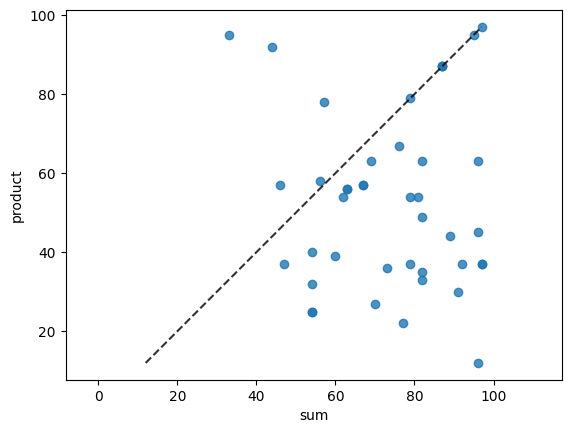

In [99]:
import matplotlib.pyplot as plt

plt.scatter(
    paired_early_cifar["epoch"]["sum"],
    paired_early_cifar["epoch"]["product"],
    alpha=0.8,
)

lo = min(
    paired_early_cifar["epoch"]["sum"].min(),
    paired_early_cifar["epoch"]["product"].min(),
)
hi = max(
    paired_early_cifar["epoch"]["sum"].max(),
    paired_early_cifar["epoch"]["product"].max(),
)

plt.plot([lo, hi], [lo, hi], "--", alpha=0.8, color="black")

plt.xlabel("sum")
plt.ylabel("product")
plt.axis("equal")

In [67]:
paired_early_cifar["mixing"]

0         sum
1     product
2         sum
3     product
4         sum
       ...   
79    product
80        sum
81    product
82        sum
83    product
Name: mixing, Length: 84, dtype: str